# Embeddings de audio con Fourier para estudiar cambios en los sonidos populares

Este notebook construye un pipeline completo para extraer embeddings directamente del audio de previews `.m4a`, hacer clustering y comparar si los sonidos populares cambian entre 2017, 2021 y 2025.

La idea no es usar generos declarados, sino un embedding rico basado en la estructura espectral del audio. Asi capturamos timbre, distribucion de energia por frecuencias y variacion temporal del sonido, que contienen mucha mas informacion que un simple tag de genero.


## Que hace el pipeline

El flujo es:

1. indexar los previews por anio;
2. decodificar cada `.m4a` a una onda mono con `ffmpeg`;
3. calcular una representacion de Fourier usando STFT;
4. resumir esa representacion en un embedding numerico fijo para cada cancion;
5. reducir dimensionalidad con PCA;
6. agrupar canciones con K-Means;
7. comparar composicion de clusters y medir diversidad por anio.

El embedding combina:

- el promedio de energia relativa por bandas de frecuencia;
- la dispersion temporal de esas bandas;
- cuanto cambia el espectro cuadro a cuadro;
- momentos espectrales como centroid, bandwidth, rolloff y flatness.


In [77]:
import os
from pathlib import Path
import subprocess

CACHE_DIR = Path.cwd() / ".cache_dir"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))

import numpy as np
import pandas as pd
from scipy import signal
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "sounds").exists() and (PROJECT_DIR / "Proyetco" / "sounds").exists():
    PROJECT_DIR = PROJECT_DIR / "Proyetco"

SOUND_ROOT = PROJECT_DIR / "sounds"
OUTPUT_DIR = PROJECT_DIR / "embedding_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_SR = 22050
N_FFT = 2048
HOP = 512
N_BINS = 48
FMIN = 40.0
RANDOM_STATE = 42
FORCE_RECOMPUTE = False

SUPPORTED_AUDIO_EXTS = {".m4a", ".mp3", ".wav", ".aac", ".mp4", ".flac", ".ogg"}

assert SOUND_ROOT.exists(), f"No existe la carpeta de audios: {SOUND_ROOT}"


## Carga de audio y construccion del embedding

Como el entorno no tiene `librosa`, decodificamos cada preview con `ffmpeg` a audio PCM mono a 22,050 Hz. Despues calculamos una STFT con ventana Hann.

A partir del espectro de Fourier construimos un embedding fijo por cancion:

- dividimos el eje de frecuencias en bandas logaritmicas;
- calculamos el share relativo de energia de cada banda en cada frame;
- resumimos cada banda con su media, su desviacion estandar y su cambio medio absoluto entre frames;
- anadimos estadisticos globales del espectro.

Eso produce un vector numerico comparable entre canciones aunque los archivos tengan duraciones ligeramente distintas.


In [78]:
def infer_year_from_path(audio_path: Path, sound_root: Path) -> int:
    rel_parts = audio_path.relative_to(sound_root).parts
    for part in reversed(rel_parts[:-1]):
        if part.isdigit() and len(part) == 4:
            return int(part)
    raise ValueError(f"No pude inferir el anio para: {audio_path}")


def collect_audio_index(sound_root: Path) -> pd.DataFrame:
    rows = []
    for audio_path in sorted(p for p in sound_root.rglob("*") if p.is_file() and p.suffix.lower() in SUPPORTED_AUDIO_EXTS):
        year = infer_year_from_path(audio_path, sound_root)
        rows.append(
            {
                "year": year,
                "file_name": audio_path.name,
                "track_stub": audio_path.stem,
                "path": str(audio_path.resolve()),
                "relative_path": str(audio_path.relative_to(sound_root)),
                "extension": audio_path.suffix.lower(),
            }
        )

    audio_index = pd.DataFrame(rows)
    if audio_index.empty:
        raise ValueError(f"No se encontraron audios bajo {sound_root}")

    audio_index = audio_index.sort_values(["year", "relative_path"]).reset_index(drop=True)
    return audio_index


def decode_audio_ffmpeg(path: str, sr: int = TARGET_SR) -> np.ndarray:
    cmd = [
        "ffmpeg",
        "-v",
        "error",
        "-i",
        path,
        "-ac",
        "1",
        "-ar",
        str(sr),
        "-f",
        "s16le",
        "-acodec",
        "pcm_s16le",
        "-",
    ]
    raw = subprocess.run(cmd, capture_output=True, check=True).stdout
    y = np.frombuffer(raw, dtype=np.int16).astype(np.float32) / 32768.0
    if y.size == 0:
        raise ValueError(f"Audio vacio: {path}")
    return y


def get_frequency_bins(sr: int, n_bins: int = N_BINS, fmin: float = FMIN):
    edges = np.geomspace(fmin, sr / 2, n_bins + 1)
    centers = np.sqrt(edges[:-1] * edges[1:])
    return edges, centers


def spectral_rolloff(rel_power: np.ndarray, freqs: np.ndarray, threshold: float = 0.85) -> np.ndarray:
    cumulative = np.cumsum(rel_power, axis=0)
    idx = (cumulative >= threshold).argmax(axis=0)
    return freqs[idx]


def extract_fourier_embedding(
    y: np.ndarray,
    sr: int = TARGET_SR,
    n_fft: int = N_FFT,
    hop: int = HOP,
    n_bins: int = N_BINS,
    fmin: float = FMIN,
):
    if y.size < n_fft:
        y = np.pad(y, (0, n_fft - y.size))

    freqs, _, zxx = signal.stft(
        y,
        fs=sr,
        window="hann",
        nperseg=n_fft,
        noverlap=n_fft - hop,
        boundary=None,
        padded=False,
    )

    power = np.abs(zxx) ** 2 + 1e-12
    valid = freqs >= fmin
    freqs = freqs[valid]
    power = power[valid]

    frame_energy = power.sum(axis=0, keepdims=True) + 1e-12
    rel_power = power / frame_energy

    edges, centers = get_frequency_bins(sr=sr, n_bins=n_bins, fmin=fmin)
    binned_frames = []
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (freqs >= edges[i]) & (freqs <= edges[i + 1])
        else:
            mask = (freqs >= edges[i]) & (freqs < edges[i + 1])
        if mask.any():
            binned_frames.append(rel_power[mask].mean(axis=0))
        else:
            binned_frames.append(np.zeros(rel_power.shape[1], dtype=np.float64))
    binned_frames = np.vstack(binned_frames)

    mean_bins = binned_frames.mean(axis=1)
    std_bins = binned_frames.std(axis=1)
    if binned_frames.shape[1] > 1:
        delta_bins = np.abs(np.diff(binned_frames, axis=1)).mean(axis=1)
    else:
        delta_bins = np.zeros(n_bins)

    centroid = (freqs[:, None] * rel_power).sum(axis=0)
    bandwidth = np.sqrt((((freqs[:, None] - centroid[None, :]) ** 2) * rel_power).sum(axis=0))
    rolloff = spectral_rolloff(rel_power, freqs, threshold=0.85)
    flatness = np.exp(np.mean(np.log(power), axis=0)) / np.mean(power, axis=0)

    low_share = rel_power[freqs < 250].sum(axis=0).mean()
    mid_share = rel_power[(freqs >= 250) & (freqs < 2000)].sum(axis=0).mean()
    high_share = rel_power[freqs >= 2000].sum(axis=0).mean()

    scalar_features = np.array(
        [
            centroid.mean(),
            centroid.std(),
            bandwidth.mean(),
            bandwidth.std(),
            rolloff.mean(),
            flatness.mean(),
            flatness.std(),
            low_share,
            mid_share,
            high_share,
        ],
        dtype=np.float64,
    )

    vector = np.concatenate([mean_bins, std_bins, delta_bins, scalar_features])
    names = (
        [f"spec_mean_bin_{i:02d}" for i in range(n_bins)]
        + [f"spec_std_bin_{i:02d}" for i in range(n_bins)]
        + [f"spec_delta_bin_{i:02d}" for i in range(n_bins)]
        + [
            "centroid_mean",
            "centroid_std",
            "bandwidth_mean",
            "bandwidth_std",
            "rolloff85_mean",
            "flatness_mean",
            "flatness_std",
            "low_share_mean",
            "mid_share_mean",
            "high_share_mean",
        ]
    )
    diagnostics = {
        "duration_seconds": y.size / sr,
        "rms": float(np.sqrt(np.mean(y ** 2))),
    }
    return vector, names, diagnostics, centers


## Extraer embeddings y guardar cache

Esta celda recorre todos los audios, calcula el embedding Fourier y guarda dos archivos en `embedding_outputs/`:

- `fourier_embedding_metadata.csv` con metadatos por cancion;
- `fourier_embedding_matrix.npy` con la matriz numerica de embeddings.

Asi no tienes que recomputar todo cada vez que abras el notebook.


In [79]:
audio_index = collect_audio_index(SOUND_ROOT)
display(audio_index.groupby("year").size().rename("n_canciones").to_frame())
display(audio_index.head())
print(f"Audios detectados en disco: {len(audio_index)}")

metadata_path = OUTPUT_DIR / "fourier_embedding_metadata.csv"
matrix_path = OUTPUT_DIR / "fourier_embedding_matrix.npy"

cache_is_valid = False
if metadata_path.exists() and matrix_path.exists() and not FORCE_RECOMPUTE:
    embedding_df = pd.read_csv(metadata_path)
    X = np.load(matrix_path)
    cached_paths = set(embedding_df.get("path", pd.Series(dtype=str)).astype(str))
    indexed_paths = set(audio_index["path"].astype(str))
    cache_is_valid = X.shape[0] == len(embedding_df) == len(audio_index) and cached_paths == indexed_paths

    if cache_is_valid:
        feature_cols = [c for c in embedding_df.columns if c.startswith("feat_")]
        freq_centers = get_frequency_bins(TARGET_SR, N_BINS, FMIN)[1]
        print(f"Cache cargado: {X.shape[0]} canciones, {X.shape[1]} features")
    else:
        print("Cache desactualizado: el inventario de audios cambio. Se regeneraran embeddings.")

if not cache_is_valid:
    rows = []
    vectors = []
    feature_names = None
    freq_centers = None

    for idx, row in audio_index.iterrows():
        if idx % 25 == 0:
            print(f"Procesando {idx + 1}/{len(audio_index)}")

        y = decode_audio_ffmpeg(row["path"], sr=TARGET_SR)
        vector, names, diagnostics, freq_centers = extract_fourier_embedding(y)

        if feature_names is None:
            feature_names = names

        vectors.append(vector)
        rows.append(
            {
                "year": row["year"],
                "file_name": row["file_name"],
                "track_stub": row["track_stub"],
                "path": row["path"],
                "relative_path": row["relative_path"],
                "extension": row["extension"],
                "duration_seconds": diagnostics["duration_seconds"],
                "rms": diagnostics["rms"],
            }
        )

    X = np.vstack(vectors)
    embedding_df = pd.DataFrame(rows)
    feature_cols = [f"feat_{name}" for name in feature_names]
    feature_df = pd.DataFrame(X, columns=feature_cols)
    embedding_df = pd.concat([embedding_df, feature_df], axis=1)

    embedding_df.to_csv(metadata_path, index=False)
    np.save(matrix_path, X)
    print(f"Cache guardado en: {OUTPUT_DIR}")

print(embedding_df.shape)
display(embedding_df[["year", "file_name", "duration_seconds", "rms"]].head())


,n_canciones
year,
2017,643
2021,499
2025,368


,year,file_name,track_stub,path,relative_path,extension
0,2017,...Ready_For_It___Taylor_Swift.m4a,...Ready_For_It___Taylor_Swift,/Users/emiliahernandez/Desktop/desarrollo/Proy...,apple_previews/2017/...Ready_For_It___Taylor_S...,.m4a
1,2017,1-800-273-8255__Logic.m4a,1-800-273-8255__Logic,/Users/emiliahernandez/Desktop/desarrollo/Proy...,apple_previews/2017/1-800-273-8255__Logic.m4a,.m4a
2,2017,24K_Magic__Bruno_Mars.m4a,24K_Magic__Bruno_Mars,/Users/emiliahernandez/Desktop/desarrollo/Proy...,apple_previews/2017/24K_Magic__Bruno_Mars.m4a,.m4a
3,2017,2U_feat._Justin_Bieber___David_Guetta.m4a,2U_feat._Justin_Bieber___David_Guetta,/Users/emiliahernandez/Desktop/desarrollo/Proy...,apple_previews/2017/2U_feat._Justin_Bieber___D...,.m4a
4,2017,3_A.M.__Jesse_Joy.m4a,3_A.M.__Jesse_Joy,/Users/emiliahernandez/Desktop/desarrollo/Proy...,apple_previews/2017/3_A.M.__Jesse_Joy.m4a,.m4a


Audios detectados en disco: 1510
Cache cargado: 1510 canciones, 154 features
(1510, 162)


,year,file_name,duration_seconds,rms
0,2017,...Ready_For_It___Taylor_Swift.m4a,29.97551,0.252033
1,2017,1-800-273-8255__Logic.m4a,29.97551,0.290224
2,2017,24K_Magic__Bruno_Mars.m4a,29.92907,0.256446
3,2017,2U_feat._Justin_Bieber___David_Guetta.m4a,29.92907,0.341311
4,2017,3_A.M.__Jesse_Joy.m4a,29.92907,0.378514


## Reducir dimensionalidad y hacer clustering

Los embeddings tienen muchas dimensiones. Primero los estandarizamos, luego aplicamos PCA para compactar la informacion y finalmente usamos K-Means.

No fijamos el numero de clusters a mano: probamos varios valores de `k` y usamos el `silhouette score` para elegir un punto de partida razonable. Esto no prueba una verdad unica, pero si da una particion defensible para explorar patrones.


In [80]:
X = embedding_df[feature_cols].to_numpy(dtype=float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.searchsorted(cum_var, 0.90) + 1)

pca = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
X_pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

k_grid = list(range(3, 9))
model_selection = []
for k in k_grid:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    model_selection.append({"k": k, "silhouette": sil, "inertia": km.inertia_})

model_selection = pd.DataFrame(model_selection)
display(model_selection)

best_k = int(model_selection.sort_values("silhouette", ascending=False).iloc[0]["k"])
print(f"k elegido por silhouette: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
embedding_df["cluster"] = kmeans.fit_predict(X_pca)
embedding_df["pca1"] = X_pca_2d[:, 0]
embedding_df["pca2"] = X_pca_2d[:, 1]

cluster_share = pd.crosstab(embedding_df["year"], embedding_df["cluster"], normalize="index")
display(cluster_share)

clusters_by_year = (
    embedding_df.groupby("year")["cluster"]
    .nunique()
    .rename("n_clusters_observed")
    .reset_index()
)
display(clusters_by_year)


,k,silhouette,inertia
0,3,0.112120,159494.053825
1,4,0.100198,151714.277614
2,5,0.087906,145573.392910
3,6,0.072397,140585.410997
4,7,0.064789,136634.024292
5,8,0.066180,133770.833301


k elegido por silhouette: 3


cluster,0,1,2
year,,,
2017,0.362364,0.443235,0.194401
2021,0.276553,0.420842,0.302605
2025,0.233696,0.440217,0.326087


,year,n_clusters_observed
0,2017,3
1,2021,3
2,2025,3


## Visualizaciones del espacio de audio y de la composicion de clusters

Las siguientes graficas responden preguntas distintas:

- el scatter en PCA sirve para ver si las canciones de distintos anios ocupan zonas parecidas o distintas del espacio sonoro;
- el scatter coloreado por cluster muestra la particion estimada por K-Means;
- la barra apilada por anio permite ver si la mezcla de sonidos populares cambia en el tiempo;
- la huella espectral promedio por anio resume si la energia se desplaza hacia bandas distintas.


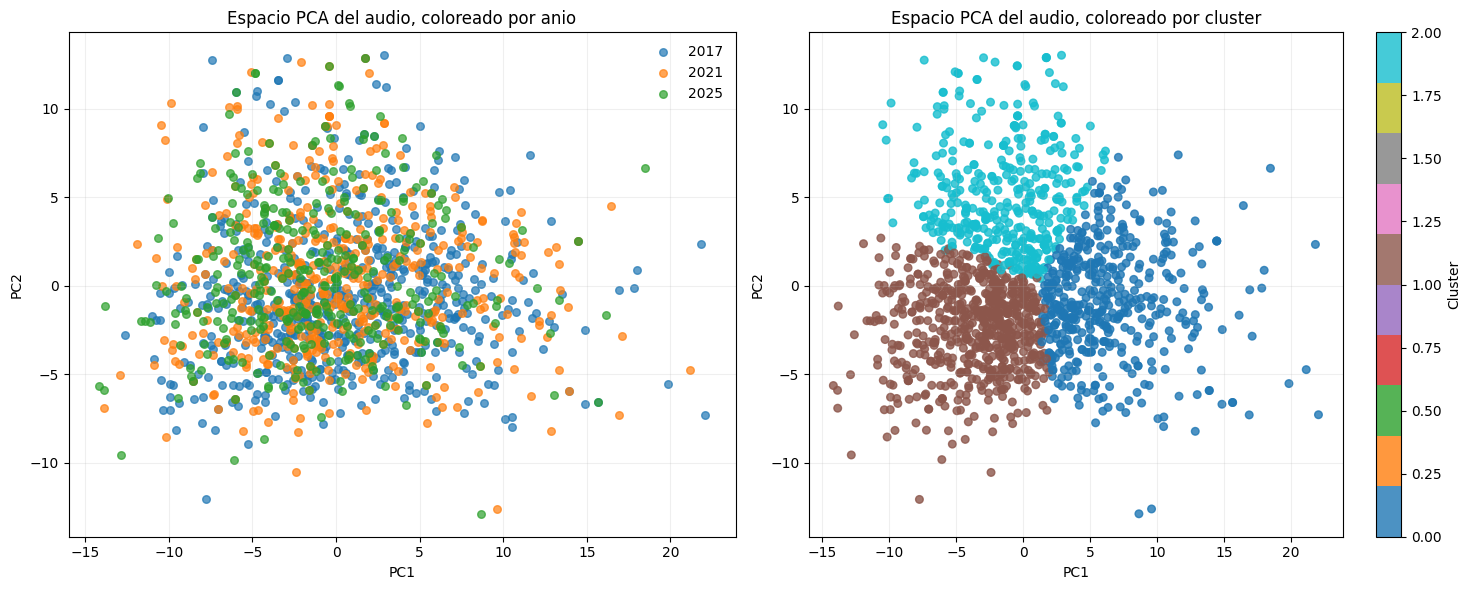

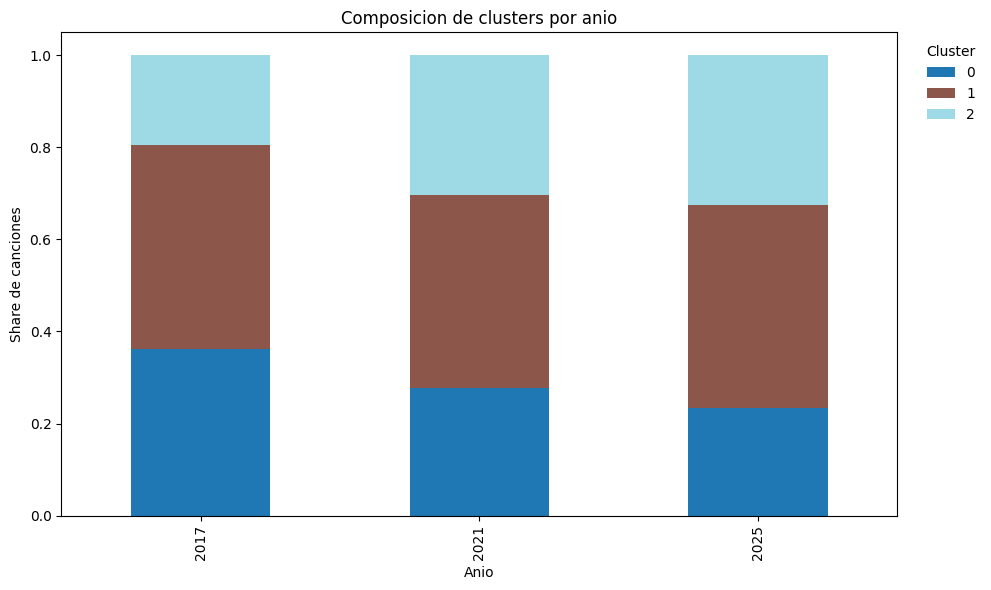

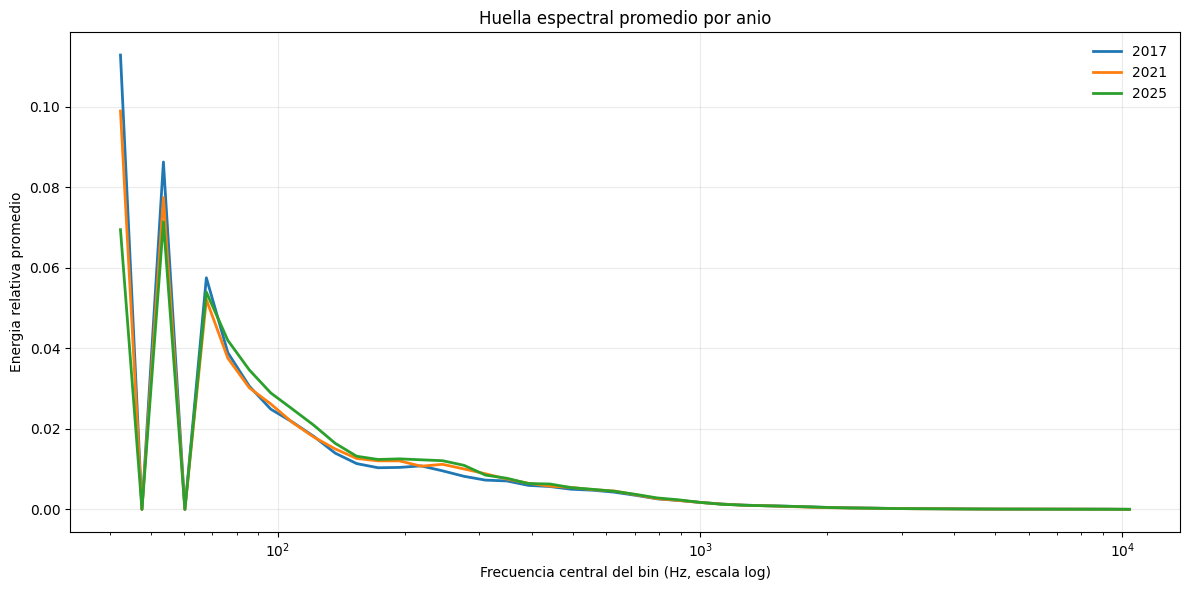

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for year, sub in embedding_df.groupby("year"):
    axes[0].scatter(sub["pca1"], sub["pca2"], s=30, alpha=0.7, label=str(year))
axes[0].set_title("Espacio PCA del audio, coloreado por anio")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

scatter = axes[1].scatter(
    embedding_df["pca1"],
    embedding_df["pca2"],
    c=embedding_df["cluster"],
    cmap="tab10",
    s=30,
    alpha=0.8,
)
axes[1].set_title("Espacio PCA del audio, coloreado por cluster")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(alpha=0.2)
plt.colorbar(scatter, ax=axes[1], label="Cluster")
plt.tight_layout()
plt.show()

cluster_share.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.title("Composicion de clusters por anio")
plt.xlabel("Anio")
plt.ylabel("Share de canciones")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

spec_mean_cols = [c for c in feature_cols if c.startswith("feat_spec_mean_bin_")]
year_spectra = embedding_df.groupby("year")[spec_mean_cols].mean()

plt.figure(figsize=(12, 6))
for year in year_spectra.index:
    plt.plot(freq_centers, year_spectra.loc[year].to_numpy(), linewidth=2, label=str(year))
plt.xscale("log")
plt.title("Huella espectral promedio por anio")
plt.xlabel("Frecuencia central del bin (Hz, escala log)")
plt.ylabel("Energia relativa promedio")
plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Medir diversidad sonora en el tiempo

Para evaluar si los sonidos populares son mas diversos, usamos tres medidas por anio:

- **entropia de clusters**: aumenta cuando la masa se reparte mas uniformemente entre clusters;
- **numero efectivo de clusters**: `exp(entropia)`, una forma mas interpretable de leer la entropia;
- **distancia media par a par en el embedding**: mide dispersion geometrica directa en el espacio sonoro.

Si 2025 tiene valores mas altos que 2017, eso es consistente con mayor diversidad de sonidos populares. Si no, sugiere mas concentracion o mayor homogeneidad sonora.


,year,n_clusters_observed,entropy_clusters,effective_clusters,avg_pairwise_distance,n_tracks
0,2017,3,1.046875,2.848734,871.777383,643
1,2021,3,1.081418,2.948858,874.869941,499
2,2025,3,1.066334,2.904712,821.889797,368


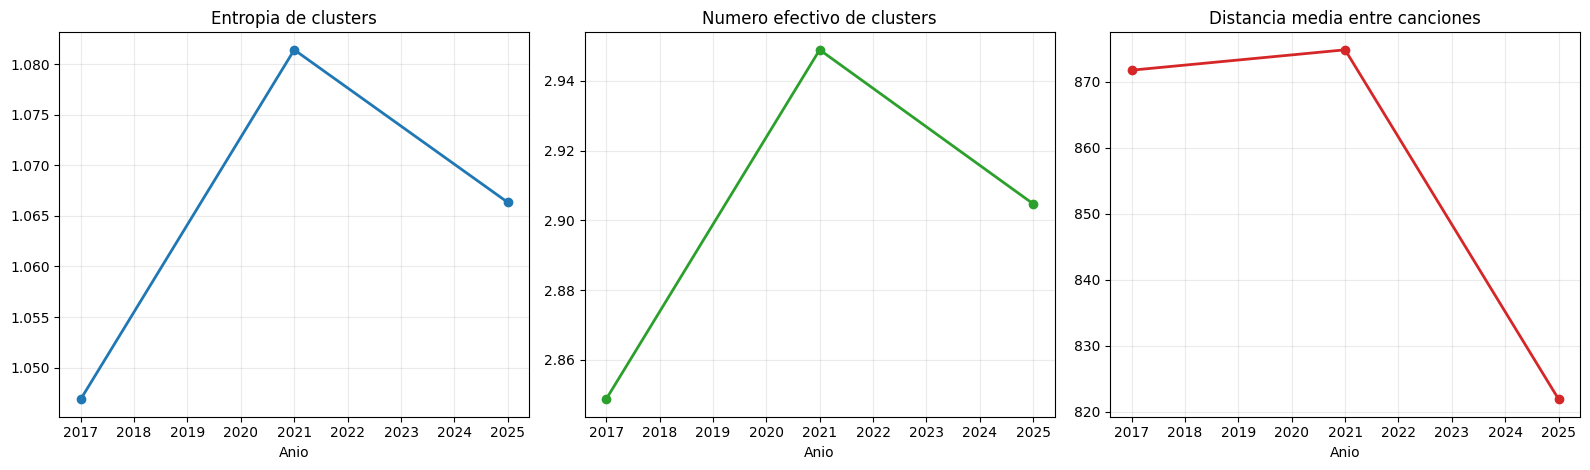

Resultados guardados en /Users/emiliahernandez/Desktop/desarrollo/Proyetco/embedding_outputs


In [82]:
diversity_rows = []
for year, sub in embedding_df.groupby("year"):
    shares = sub["cluster"].value_counts(normalize=True).sort_index().to_numpy()
    entropy = float(-(shares * np.log(shares + 1e-12)).sum())
    effective_clusters = float(np.exp(entropy))
    avg_pairwise_distance = float(pdist(sub[feature_cols].to_numpy(dtype=float), metric="euclidean").mean())

    diversity_rows.append(
        {
            "year": int(year),
            "n_clusters_observed": int(sub["cluster"].nunique()),
            "entropy_clusters": entropy,
            "effective_clusters": effective_clusters,
            "avg_pairwise_distance": avg_pairwise_distance,
            "n_tracks": int(len(sub)),
        }
    )

diversity_df = pd.DataFrame(diversity_rows).sort_values("year")
display(diversity_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(diversity_df["year"], diversity_df["entropy_clusters"], marker="o", linewidth=2)
axes[0].set_title("Entropia de clusters")
axes[0].set_xlabel("Anio")
axes[0].grid(alpha=0.25)

axes[1].plot(diversity_df["year"], diversity_df["effective_clusters"], marker="o", linewidth=2, color="tab:green")
axes[1].set_title("Numero efectivo de clusters")
axes[1].set_xlabel("Anio")
axes[1].grid(alpha=0.25)

axes[2].plot(diversity_df["year"], diversity_df["avg_pairwise_distance"], marker="o", linewidth=2, color="tab:red")
axes[2].set_title("Distancia media entre canciones")
axes[2].set_xlabel("Anio")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

embedding_df.to_csv(OUTPUT_DIR / "fourier_embedding_analysis.csv", index=False)
diversity_df.to_csv(OUTPUT_DIR / "fourier_diversity_by_year.csv", index=False)
print(f"Resultados guardados en {OUTPUT_DIR}")


## Embeddings neuronales con autoencoder profundo

En esta seccion dejamos de construir el embedding a mano y pasamos a **aprenderlo** con una red neuronal. La idea es representar cada preview como un **log-mel espectrograma** de tamano fijo y entrenar un **autoencoder profundo** que aprenda a reconstruirlo.

El modelo funciona asi:

1. cada audio se decodifica con `ffmpeg`;
2. se transforma a un log-mel espectrograma, que conserva estructura tiempo-frecuencia;
3. ese tensor se aplana y entra a un **MLP profundo simetrico** con una activacion densa y un cuello de botella;
4. la red intenta reconstruir su propia entrada;
5. la activacion del cuello de botella se usa como **embedding neuronal**;
6. si alguna dimension queda muerta o constante, se elimina antes del analisis.

Este embedding sirve para capturar relaciones **no lineales** entre patrones de timbre, energia, textura y dinamica que un resumen manual puede perder. No usa etiquetas: aprende una geometria del audio directamente desde los previews y luego usamos esa geometria para hacer el mismo analisis de PCA, clustering y diversidad entre anios.

Nota practica: en este entorno no hay `torch` ni `tensorflow`, asi que implementamos el autoencoder con `scikit-learn` (`MLPRegressor`) para que el notebook corra con tus dependencias actuales.


In [83]:
NEURAL_LATENT_DIM = 64
NEURAL_MEL_BINS = 48
NEURAL_TIME_STEPS = 48
NEURAL_FMAX = 8000.0
NEURAL_MAX_ITER = 80
NEURAL_HIDDEN_ACTIVATION = "tanh"
NEURAL_FORCE_RECOMPUTE = False
NEURAL_MODEL_SIGNATURE = "logmel_48x48_mlp_256_128_latent64_tanh_v2"


def hz_to_mel(freq_hz: np.ndarray) -> np.ndarray:
    return 2595.0 * np.log10(1.0 + np.asarray(freq_hz) / 700.0)


def mel_to_hz(mels: np.ndarray) -> np.ndarray:
    return 700.0 * (10 ** (np.asarray(mels) / 2595.0) - 1.0)


def build_mel_filterbank(sr: int, n_fft: int, n_mels: int, fmin: float, fmax: float) -> np.ndarray:
    fft_freqs = np.linspace(0, sr / 2, n_fft // 2 + 1)
    mel_edges = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_edges = mel_to_hz(mel_edges)

    filters = np.zeros((n_mels, len(fft_freqs)), dtype=np.float64)
    for i in range(n_mels):
        left, center, right = hz_edges[i : i + 3]
        left_mask = (fft_freqs >= left) & (fft_freqs <= center)
        right_mask = (fft_freqs >= center) & (fft_freqs <= right)

        if center > left:
            filters[i, left_mask] = (fft_freqs[left_mask] - left) / (center - left)
        if right > center:
            filters[i, right_mask] = (right - fft_freqs[right_mask]) / (right - center)

    filters /= filters.sum(axis=1, keepdims=True) + 1e-12
    return filters


NEURAL_MEL_FILTERBANK = build_mel_filterbank(
    sr=TARGET_SR,
    n_fft=N_FFT,
    n_mels=NEURAL_MEL_BINS,
    fmin=FMIN,
    fmax=NEURAL_FMAX,
)


def build_log_mel_snapshot(
    y: np.ndarray,
    sr: int = TARGET_SR,
    n_fft: int = N_FFT,
    hop: int = HOP,
    mel_filterbank: np.ndarray = NEURAL_MEL_FILTERBANK,
    fmin: float = FMIN,
    fmax: float = NEURAL_FMAX,
    time_steps: int = NEURAL_TIME_STEPS,
) -> np.ndarray:
    if y.size < n_fft:
        y = np.pad(y, (0, n_fft - y.size))

    freqs, _, zxx = signal.stft(
        y,
        fs=sr,
        window="hann",
        nperseg=n_fft,
        noverlap=n_fft - hop,
        boundary=None,
        padded=False,
    )

    power = np.abs(zxx) ** 2 + 1e-10
    valid = (freqs >= fmin) & (freqs <= fmax)
    power = power[valid]
    mel_bank = mel_filterbank[:, valid]

    mel_power = mel_bank @ power
    log_mel = np.log1p(mel_power)

    if log_mel.shape[1] == 0:
        raise ValueError("No se pudo construir un espectrograma temporal para este audio")
    if log_mel.shape[1] == 1:
        log_mel = np.repeat(log_mel, time_steps, axis=1)
    else:
        log_mel = signal.resample(log_mel, time_steps, axis=1)

    snapshot = log_mel.astype(np.float32)
    snapshot = (snapshot - snapshot.mean()) / (snapshot.std() + 1e-6)
    return snapshot.reshape(-1)


def apply_activation(x: np.ndarray, activation: str) -> np.ndarray:
    if activation == "tanh":
        return np.tanh(x)
    if activation == "relu":
        return np.maximum(x, 0.0)
    if activation == "logistic":
        return 1.0 / (1.0 + np.exp(-x))
    if activation == "identity":
        return x
    raise ValueError(f"Activacion no soportada: {activation}")


def forward_to_hidden_layer(model: MLPRegressor, X: np.ndarray, hidden_layer_index: int) -> np.ndarray:
    activation = X
    for layer_idx, (weights, bias) in enumerate(zip(model.coefs_[:-1], model.intercepts_[:-1])):
        activation = activation @ weights + bias
        activation = apply_activation(activation, model.activation)
        if layer_idx == hidden_layer_index:
            return activation
    raise ValueError("No existe esa capa oculta en el autoencoder")


neural_metadata_path = OUTPUT_DIR / "neural_embedding_metadata.csv"
neural_matrix_path = OUTPUT_DIR / "neural_embedding_matrix.npy"

neural_cache_valid = False
if neural_metadata_path.exists() and neural_matrix_path.exists() and not NEURAL_FORCE_RECOMPUTE:
    neural_embedding_df = pd.read_csv(neural_metadata_path)
    Z_neural = np.load(neural_matrix_path)
    cached_paths = set(neural_embedding_df.get("path", pd.Series(dtype=str)).astype(str))
    indexed_paths = set(audio_index["path"].astype(str))
    cached_signature = neural_embedding_df.get("model_signature", pd.Series(dtype=str)).astype(str)
    signature_matches = (
        len(cached_signature) == len(neural_embedding_df)
        and len(cached_signature) > 0
        and set(cached_signature) == {NEURAL_MODEL_SIGNATURE}
    )
    neural_cache_valid = (
        len(neural_embedding_df) == len(audio_index) == Z_neural.shape[0]
        and cached_paths == indexed_paths
        and signature_matches
    )

    if neural_cache_valid:
        neural_feature_cols = [c for c in neural_embedding_df.columns if c.startswith("neural_feat_")]
        print(f"Cache neuronal cargado: {Z_neural.shape[0]} canciones, {Z_neural.shape[1]} features")
    else:
        print("Cache neuronal desactualizado: cambiaron los audios o la firma del modelo. Se regeneraran embeddings aprendidos.")

if not neural_cache_valid:
    neural_rows = []
    neural_inputs = []

    for idx, row in audio_index.iterrows():
        if idx % 25 == 0:
            print(f"Preparando entrada neuronal {idx + 1}/{len(audio_index)}")

        y = decode_audio_ffmpeg(row["path"], sr=TARGET_SR)
        neural_inputs.append(build_log_mel_snapshot(y))
        neural_rows.append(
            {
                "year": row["year"],
                "file_name": row["file_name"],
                "track_stub": row["track_stub"],
                "model_signature": NEURAL_MODEL_SIGNATURE,
                "path": row["path"],
                "relative_path": row.get("relative_path", row["file_name"]),
                "extension": row.get("extension", Path(row["path"]).suffix.lower()),
            }
        )

    X_neural_input = np.vstack(neural_inputs).astype(np.float32)
    neural_input_scaler = StandardScaler()
    X_neural_scaled = neural_input_scaler.fit_transform(X_neural_input)

    autoencoder = MLPRegressor(
        hidden_layer_sizes=(256, 128, NEURAL_LATENT_DIM, 128, 256),
        activation=NEURAL_HIDDEN_ACTIVATION,
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=NEURAL_MAX_ITER,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=8,
        random_state=RANDOM_STATE,
        verbose=True,
    )
    autoencoder.fit(X_neural_scaled, X_neural_scaled)
    reconstruction = autoencoder.predict(X_neural_scaled)
    reconstruction_mse = float(np.mean((X_neural_scaled - reconstruction) ** 2))

    Z_neural_full = forward_to_hidden_layer(autoencoder, X_neural_scaled, hidden_layer_index=2).astype(np.float32)
    latent_std = Z_neural_full.std(axis=0)
    active_mask = latent_std > 1e-6
    if not np.any(active_mask):
        raise ValueError("El embedding neuronal colapso: todas las dimensiones latentes quedaron constantes")

    Z_neural = Z_neural_full[:, active_mask]
    neural_feature_cols = [f"neural_feat_{i:03d}" for i in range(Z_neural.shape[1])]
    print(f"Recon MSE: {reconstruction_mse:.6f}")
    print(f"Dimensiones latentes activas: {Z_neural.shape[1]}/{Z_neural_full.shape[1]}")

    neural_embedding_df = pd.DataFrame(neural_rows)
    neural_feature_df = pd.DataFrame(Z_neural, columns=neural_feature_cols)
    neural_embedding_df = pd.concat([neural_embedding_df, neural_feature_df], axis=1)

    neural_embedding_df.to_csv(neural_metadata_path, index=False)
    np.save(neural_matrix_path, Z_neural)
    print(f"Embeddings neuronales guardados en: {OUTPUT_DIR}")

print(neural_embedding_df.shape)
display(neural_embedding_df[["year", "file_name"] + neural_feature_cols[:6]].head())


Cache neuronal cargado: 1510 canciones, 64 features
(1510, 71)


,year,file_name,neural_feat_000,neural_feat_001,neural_feat_002,neural_feat_003,neural_feat_004,neural_feat_005
0,2017,...Ready_For_It___Taylor_Swift.m4a,-0.465723,0.785811,-0.831581,0.650897,-0.199191,-0.226076
1,2017,1-800-273-8255__Logic.m4a,0.998952,0.497922,-0.171342,0.929715,-0.653649,-0.971919
2,2017,24K_Magic__Bruno_Mars.m4a,0.607416,0.763926,-0.860830,-0.127793,-0.752801,-0.566001
3,2017,2U_feat._Justin_Bieber___David_Guetta.m4a,-0.930387,0.631435,-0.756317,-0.570380,-0.173826,0.350722
4,2017,3_A.M.__Jesse_Joy.m4a,0.996237,0.921216,0.708981,0.732390,-0.884211,-0.976180


## Analisis de embeddings neuronales

A partir del embedding aprendido por el autoencoder, repetimos exactamente el mismo esquema analitico: estandarizacion, PCA, seleccion de `k` por `silhouette`, clustering con K-Means y comparacion de diversidad por anio.

La diferencia es que ahora el espacio geometrico no viene de reglas manuales de Fourier sino de una representacion **aprendida** que intenta preservar regularidades profundas del audio al reconstruirlo.


,k,silhouette,inertia
0,3,0.348071,41256.110978
1,4,0.256746,36372.939507
2,5,0.208456,34658.616372
3,6,0.164919,33303.617295
4,7,0.143585,32113.860130
5,8,0.138903,31143.433935


k neuronal elegido por silhouette: 3


cluster,0,1,2
year,,,
2017,0.262830,0.547434,0.189736
2021,0.270541,0.519038,0.210421
2025,0.404891,0.307065,0.288043


,year,n_clusters_observed
0,2017,3
1,2021,3
2,2025,3


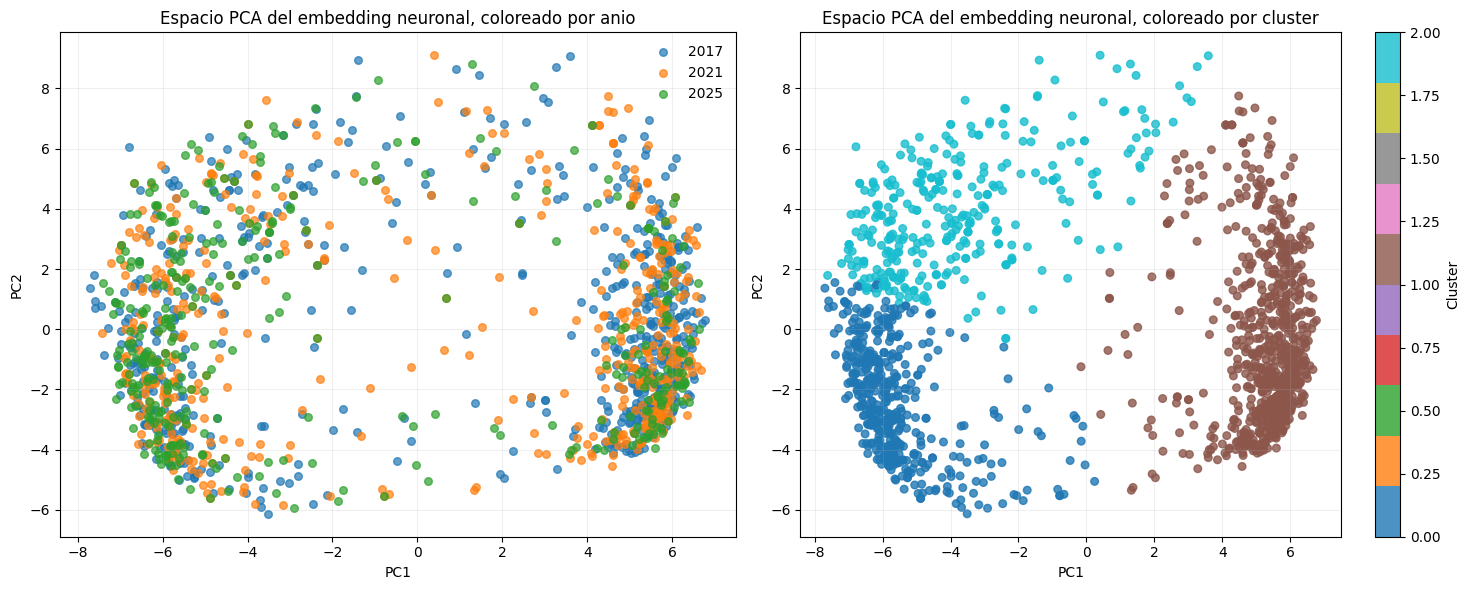

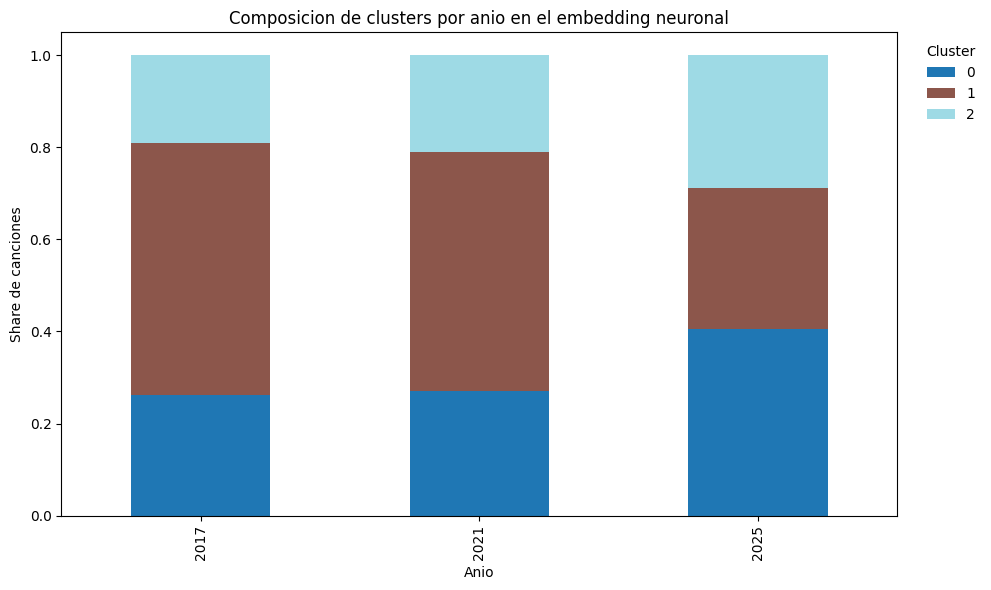

,year,n_clusters_observed,entropy_clusters,effective_clusters,avg_pairwise_distance,n_tracks
0,2017,3,0.996407,2.708531,6.689620,643
1,2021,3,1.022032,2.778836,6.804497,499
2,2025,3,1.087139,2.965777,6.871481,368


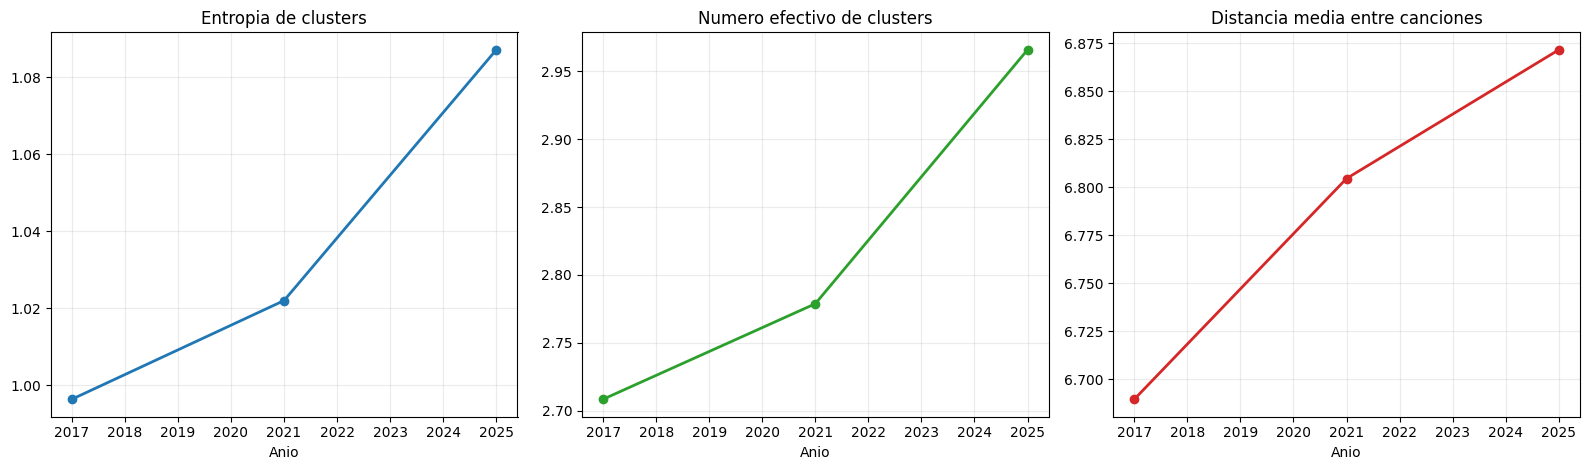

Resultados neuronales guardados en /Users/emiliahernandez/Desktop/desarrollo/Proyetco/embedding_outputs


In [84]:
X_neural = neural_embedding_df[neural_feature_cols].to_numpy(dtype=float)

neural_scaler = StandardScaler()
X_neural_scaled = neural_scaler.fit_transform(X_neural)

neural_pca_full = PCA(random_state=RANDOM_STATE)
neural_pca_full.fit(X_neural_scaled)
neural_cum_var = np.cumsum(neural_pca_full.explained_variance_ratio_)
neural_n_components_90 = int(np.searchsorted(neural_cum_var, 0.90) + 1)

neural_pca = PCA(n_components=neural_n_components_90, random_state=RANDOM_STATE)
X_neural_pca = neural_pca.fit_transform(X_neural_scaled)
X_neural_pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_neural_scaled)

neural_k_grid = list(range(3, 9))
neural_model_selection = []
for k in neural_k_grid:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_neural_pca)
    sil = silhouette_score(X_neural_pca, labels)
    neural_model_selection.append({"k": k, "silhouette": sil, "inertia": km.inertia_})

neural_model_selection = pd.DataFrame(neural_model_selection)
display(neural_model_selection)

neural_best_k = int(neural_model_selection.sort_values("silhouette", ascending=False).iloc[0]["k"])
print(f"k neuronal elegido por silhouette: {neural_best_k}")

neural_kmeans = KMeans(n_clusters=neural_best_k, random_state=RANDOM_STATE, n_init=20)
neural_embedding_df["cluster"] = neural_kmeans.fit_predict(X_neural_pca)
neural_embedding_df["pca1"] = X_neural_pca_2d[:, 0]
neural_embedding_df["pca2"] = X_neural_pca_2d[:, 1]

neural_cluster_share = pd.crosstab(neural_embedding_df["year"], neural_embedding_df["cluster"], normalize="index")
display(neural_cluster_share)

neural_clusters_by_year = (
    neural_embedding_df.groupby("year")["cluster"]
    .nunique()
    .rename("n_clusters_observed")
    .reset_index()
)
display(neural_clusters_by_year)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for year, sub in neural_embedding_df.groupby("year"):
    axes[0].scatter(sub["pca1"], sub["pca2"], s=30, alpha=0.7, label=str(year))
axes[0].set_title("Espacio PCA del embedding neuronal, coloreado por anio")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

scatter = axes[1].scatter(
    neural_embedding_df["pca1"],
    neural_embedding_df["pca2"],
    c=neural_embedding_df["cluster"],
    cmap="tab10",
    s=30,
    alpha=0.8,
)
axes[1].set_title("Espacio PCA del embedding neuronal, coloreado por cluster")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(alpha=0.2)
plt.colorbar(scatter, ax=axes[1], label="Cluster")
plt.tight_layout()
plt.show()

neural_cluster_share.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.title("Composicion de clusters por anio en el embedding neuronal")
plt.xlabel("Anio")
plt.ylabel("Share de canciones")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

neural_diversity_rows = []
for year, sub in neural_embedding_df.groupby("year"):
    shares = sub["cluster"].value_counts(normalize=True).sort_index().to_numpy()
    entropy = float(-(shares * np.log(shares + 1e-12)).sum())
    effective_clusters = float(np.exp(entropy))
    avg_pairwise_distance = float(pdist(sub[neural_feature_cols].to_numpy(dtype=float), metric="euclidean").mean())

    neural_diversity_rows.append(
        {
            "year": int(year),
            "n_clusters_observed": int(sub["cluster"].nunique()),
            "entropy_clusters": entropy,
            "effective_clusters": effective_clusters,
            "avg_pairwise_distance": avg_pairwise_distance,
            "n_tracks": int(len(sub)),
        }
    )

neural_diversity_df = pd.DataFrame(neural_diversity_rows).sort_values("year")
display(neural_diversity_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(neural_diversity_df["year"], neural_diversity_df["entropy_clusters"], marker="o", linewidth=2)
axes[0].set_title("Entropia de clusters")
axes[0].set_xlabel("Anio")
axes[0].grid(alpha=0.25)

axes[1].plot(neural_diversity_df["year"], neural_diversity_df["effective_clusters"], marker="o", linewidth=2, color="tab:green")
axes[1].set_title("Numero efectivo de clusters")
axes[1].set_xlabel("Anio")
axes[1].grid(alpha=0.25)

axes[2].plot(neural_diversity_df["year"], neural_diversity_df["avg_pairwise_distance"], marker="o", linewidth=2, color="tab:red")
axes[2].set_title("Distancia media entre canciones")
axes[2].set_xlabel("Anio")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

neural_embedding_df.to_csv(OUTPUT_DIR / "neural_embedding_analysis.csv", index=False)
neural_diversity_df.to_csv(OUTPUT_DIR / "neural_diversity_by_year.csv", index=False)
print(f"Resultados neuronales guardados en {OUTPUT_DIR}")


## Clustering por anio usando solo distancias dentro de cada anio

La logica de esta seccion es distinta al clustering global. Aqui no fijamos una particion comun para todos los anios ni miramos shares despues. En cambio, para cada anio por separado, tomamos sus puntos en el embedding neuronal y preguntamos: **cuantos clusters se forman naturalmente dentro de ese anio** segun sus distancias internas.

El procedimiento es:

1. tomar solo las canciones de un anio;
2. estandarizar ese subconjunto;
3. reducir dimensionalidad con PCA para estabilizar el clustering;
4. probar varios valores de `k`;
5. elegir el `k` con mejor `silhouette score` dentro de ese anio.

Si 2021 termina con mas clusters que 2017 y ademas con mayor distancia media entre puntos, eso es consistente con una musica mas diversa internamente en 2021.


,year,n_tracks,best_k,best_silhouette,avg_pairwise_distance,effective_clusters
0,2017,643,2,0.418493,6.689620,1.978211
1,2021,499,2,0.402250,6.804497,1.994505
2,2025,368,2,0.390045,6.871481,1.894578


\n=== 2017 | seleccion de k dentro del anio ===


,k,silhouette,inertia
0,2,0.418493,20475.174372
1,3,0.383811,17228.950690
2,4,0.263790,15139.860030
3,5,0.230068,14346.050714
4,6,0.170051,13679.723048
5,7,0.140613,13141.982783
6,8,0.144114,12739.173436


\n=== 2021 | seleccion de k dentro del anio ===


,k,silhouette,inertia
0,2,0.402250,16171.272308
1,3,0.344545,13823.018973
2,4,0.265629,11866.819131
3,5,0.196151,11276.006069
4,6,0.199301,10809.218852
5,7,0.170160,10388.686778
6,8,0.149743,10101.936329


\n=== 2025 | seleccion de k dentro del anio ===


,k,silhouette,inertia
0,2,0.390045,12525.268749
1,3,0.302700,10327.374048
2,4,0.254809,9455.257883
3,5,0.192497,8958.124193
4,6,0.168139,8564.017468
5,7,0.163746,8267.191833
6,8,0.156346,7986.197731


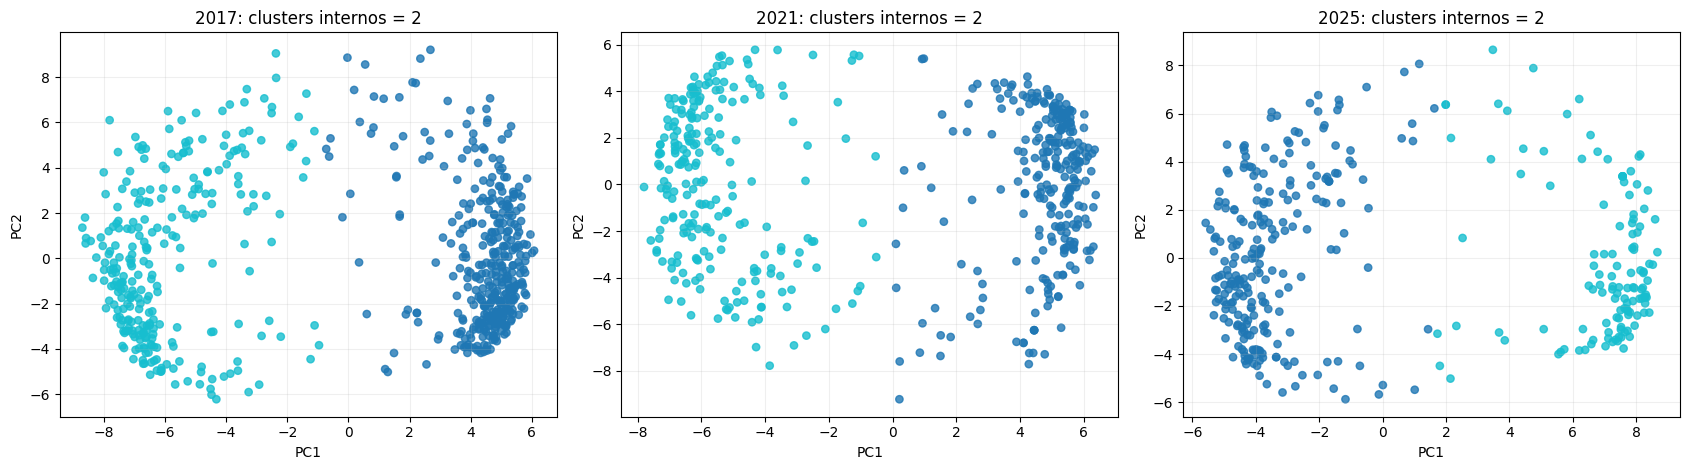

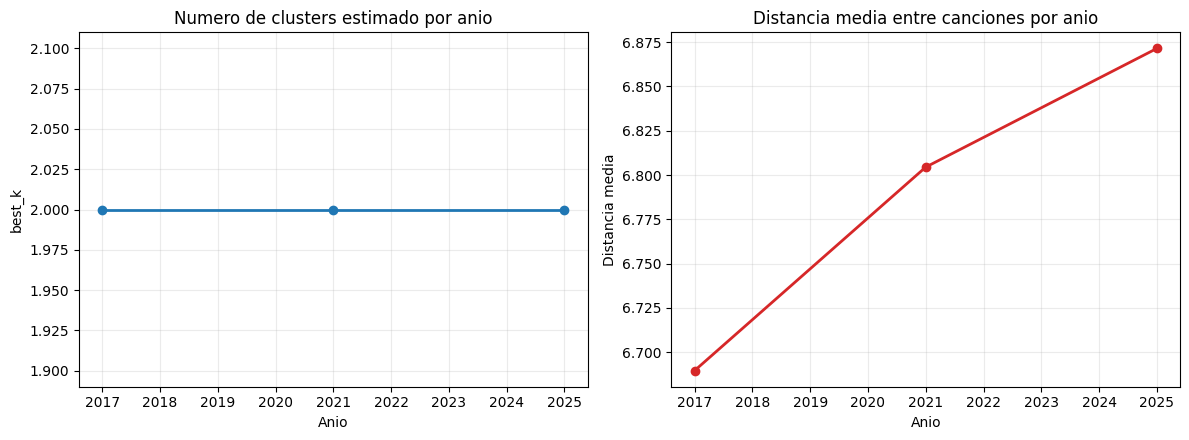

Resumen por anio guardado en /Users/emiliahernandez/Desktop/desarrollo/Proyetco/embedding_outputs/neural_yearwise_cluster_counts.csv


In [85]:
YEARWISE_MIN_K = 2
YEARWISE_MAX_K = 8


def choose_k_for_year(X_year: np.ndarray, random_state: int = RANDOM_STATE):
    n_samples = X_year.shape[0]
    if n_samples < 3:
        raise ValueError("No hay suficientes canciones para clusterizar este anio")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_year)

    max_components = min(X_scaled.shape[0], X_scaled.shape[1], 20)
    if max_components >= 2:
        pca_full = PCA(n_components=max_components, random_state=random_state)
        pca_full.fit(X_scaled)
        cum_var = np.cumsum(pca_full.explained_variance_ratio_)
        n_components = int(np.searchsorted(cum_var, 0.90) + 1)
        n_components = max(2, min(n_components, max_components))
        X_work = PCA(n_components=n_components, random_state=random_state).fit_transform(X_scaled)
    else:
        X_work = X_scaled

    k_upper = min(YEARWISE_MAX_K, n_samples - 1)
    if k_upper < YEARWISE_MIN_K:
        raise ValueError("No hay suficientes canciones para evaluar multiples clusters")

    rows = []
    for k in range(YEARWISE_MIN_K, k_upper + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = km.fit_predict(X_work)
        sil = silhouette_score(X_work, labels)
        rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})

    score_df = pd.DataFrame(rows)
    best_k = int(score_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
    best_model = KMeans(n_clusters=best_k, random_state=random_state, n_init=20)
    best_labels = best_model.fit_predict(X_work)
    return X_work, score_df, best_k, best_labels


yearwise_results = []
yearwise_score_tables = {}
yearwise_scatter = {}

for year, sub in neural_embedding_df.groupby("year"):
    X_year = sub[neural_feature_cols].to_numpy(dtype=float)
    X_work, score_df, best_k, labels = choose_k_for_year(X_year)

    yearwise_score_tables[int(year)] = score_df
    yearwise_scatter[int(year)] = {
        "coords": PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(StandardScaler().fit_transform(X_year)),
        "labels": labels,
    }

    yearwise_results.append(
        {
            "year": int(year),
            "n_tracks": int(len(sub)),
            "best_k": int(best_k),
            "best_silhouette": float(score_df.sort_values("silhouette", ascending=False).iloc[0]["silhouette"]),
            "avg_pairwise_distance": float(pdist(X_year, metric="euclidean").mean()),
            "effective_clusters": float(np.exp(-(pd.Series(labels).value_counts(normalize=True).to_numpy() * np.log(pd.Series(labels).value_counts(normalize=True).to_numpy() + 1e-12)).sum())),
        }
    )

yearwise_cluster_df = pd.DataFrame(yearwise_results).sort_values("year")
display(yearwise_cluster_df)

for year in sorted(yearwise_score_tables):
    print(f"\\n=== {year} | seleccion de k dentro del anio ===")
    display(yearwise_score_tables[year])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, year in zip(axes, sorted(yearwise_scatter)):
    coords = yearwise_scatter[year]["coords"]
    labels = yearwise_scatter[year]["labels"]
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=28, alpha=0.8)
    ax.set_title(f"{year}: clusters internos = {int(yearwise_cluster_df.loc[yearwise_cluster_df['year'] == year, 'best_k'].iloc[0])}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(yearwise_cluster_df["year"], yearwise_cluster_df["best_k"], marker="o", linewidth=2)
axes[0].set_title("Numero de clusters estimado por anio")
axes[0].set_xlabel("Anio")
axes[0].set_ylabel("best_k")
axes[0].grid(alpha=0.25)

axes[1].plot(yearwise_cluster_df["year"], yearwise_cluster_df["avg_pairwise_distance"], marker="o", linewidth=2, color="tab:red")
axes[1].set_title("Distancia media entre canciones por anio")
axes[1].set_xlabel("Anio")
axes[1].set_ylabel("Distancia media")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

yearwise_cluster_df.to_csv(OUTPUT_DIR / "neural_yearwise_cluster_counts.csv", index=False)
print(f"Resumen por anio guardado en {OUTPUT_DIR / 'neural_yearwise_cluster_counts.csv'}")


## Par mas distante dentro del mismo cluster en cada anio

Con los clusters internos estimados para cada anio, aqui buscamos el par de canciones con mayor distancia euclidiana que aun cae dentro del mismo cluster. Eso permite inspeccionar el caso mas extremo de dispersion interna por anio.


In [86]:
yearwise_farthest_pairs = []

for year, sub in neural_embedding_df.groupby("year"):
    X_year = sub[neural_feature_cols].to_numpy(dtype=float)
    _, _, _, labels = choose_k_for_year(X_year)

    sub = sub.reset_index(drop=True).copy()
    sub["year_internal_cluster"] = labels

    best_pair = None
    best_distance = -np.inf

    for cluster_id, cluster_sub in sub.groupby("year_internal_cluster"):
        if len(cluster_sub) < 2:
            continue

        idx = cluster_sub.index.to_numpy()
        X_cluster = X_year[idx]
        dist_vec = pdist(X_cluster, metric="euclidean")
        if dist_vec.size == 0:
            continue

        pair_rows, pair_cols = np.triu_indices(len(cluster_sub), k=1)
        max_pos = int(np.argmax(dist_vec))
        i_idx = idx[pair_rows[max_pos]]
        j_idx = idx[pair_cols[max_pos]]
        pair_distance = float(dist_vec[max_pos])

        if pair_distance > best_distance:
            best_distance = pair_distance
            best_pair = {
                "year": int(year),
                "cluster": int(cluster_id),
                "distance": pair_distance,
                "song_a": sub.loc[i_idx, "file_name"],
                "song_b": sub.loc[j_idx, "file_name"],
                "path_a": sub.loc[i_idx, "path"],
                "path_b": sub.loc[j_idx, "path"],
            }

    if best_pair is not None:
        yearwise_farthest_pairs.append(best_pair)

yearwise_farthest_pairs_df = pd.DataFrame(yearwise_farthest_pairs).sort_values("year")
display(yearwise_farthest_pairs_df)

yearwise_farthest_pairs_df.to_csv(OUTPUT_DIR / "neural_yearwise_farthest_same_cluster_pairs.csv", index=False)
print(f"Pares mas distantes guardados en {OUTPUT_DIR / 'neural_yearwise_farthest_same_cluster_pairs.csv'}")


,year,cluster,distance,song_a,song_b,path_a,path_b
0,2017,1,10.446808,City_Of_Stars_-_From_La_La_Land_Soundtrack__Ry...,Rollin_feat._Future_Khalid___Calvin_Harris.m4a,/Users/emiliahernandez/Desktop/desarrollo/Proy...,/Users/emiliahernandez/Desktop/desarrollo/Proy...
1,2021,0,9.643119,Alcohol-Free__TWICE.m4a,The_Business__Tiësto.m4a,/Users/emiliahernandez/Desktop/desarrollo/Proy...,/Users/emiliahernandez/Desktop/desarrollo/Proy...
2,2025,0,9.832072,Abracadabra__Lady_Gaga.m4a,WILDFLOWER__Billie_Eilish.m4a,/Users/emiliahernandez/Desktop/desarrollo/Proy...,/Users/emiliahernandez/Desktop/desarrollo/Proy...


Pares mas distantes guardados en /Users/emiliahernandez/Desktop/desarrollo/Proyetco/embedding_outputs/neural_yearwise_farthest_same_cluster_pairs.csv
